In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

2026-04-20 03:57:25.034028: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-20 03:57:26.170712: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-20 03:57:28.973409: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import Model, Input

base_model = EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

inputs = Input(shape=(224,224,3))
x = base_model(inputs)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.4)(x)
outputs = tf.keras.layers.Dense(4, activation='softmax')(x)

model = Model(inputs, outputs)

I0000 00:00:1776657453.116711     750 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1765 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [3]:
from tensorflow.keras.applications.efficientnet import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

traingenerator = train_datagen.flow_from_directory(
    'dataset/Training',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    classes=['glioma','meningioma','pituitary','notumor']  # ignore others
)

testgenerator = train_datagen.flow_from_directory(
    'dataset/Training',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    classes=['glioma','meningioma','pituitary','notumor'],
    shuffle=False
)


print(traingenerator.class_indices)

Found 4485 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
{'glioma': 0, 'meningioma': 1, 'pituitary': 2, 'notumor': 3}


In [4]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-7
    ),
    ModelCheckpoint(
        'best_brain_tumor_b0.keras',
        monitor='val_accuracy',
        save_best_only=True
    )
]

In [5]:
from sklearn.utils.class_weight import compute_class_weight

y_train = traingenerator.classes


class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))

In [6]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    traingenerator,
    validation_data=testgenerator,
    epochs=25,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/25


2026-04-20 03:57:39.889254: I external/local_xla/xla/service/service.cc:163] XLA service 0x7b8d6804aaa0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-20 03:57:39.889302: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2026-04-20 03:57:40.193890: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-20 03:57:42.039664: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-04-20 03:57:42.747024: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-20 03:57:44.

134/141 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5475 - loss: 1.1795

2026-04-20 03:58:24.756964: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-20 03:58:24.998418: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-20 03:58:25.240939: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-20 03:58:26.469090: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-20 03:58:26.750545: E external/local_xla/xla/stream_

141/141 ━━━━━━━━━━━━━━━━━━━━ 66s 250ms/step - accuracy: 0.6736 - loss: 0.8606 - val_accuracy: 0.8527 - val_loss: 0.5535 - learning_rate: 1.0000e-04
Epoch 2/25
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.8127 - loss: 0.4888 - val_accuracy: 0.8866 - val_loss: 0.3522 - learning_rate: 1.0000e-04
Epoch 3/25
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.8515 - loss: 0.3937 - val_accuracy: 0.8973 - val_loss: 0.2848 - learning_rate: 1.0000e-04
Epoch 4/25
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.8718 - loss: 0.3435 - val_accuracy: 0.9089 - val_loss: 0.2477 - learning_rate: 1.0000e-04
Epoch 5/25
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.8849 - loss: 0.2992 - val_accuracy: 0.9152 - val_loss: 0.2297 - learning_rate: 1.0000e-04
Epoch 6/25
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.9023 - loss: 0.2543 - val_accuracy: 0.9205 - val_loss: 0.2121 - learning_rate: 1.0000e-04
Epoch 7/25
141/141 ━━━━━━━━━━━━━━━━━━━━ 19s 71ms/step - accurac

In [7]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
from tensorflow.keras.metrics import Precision, Recall

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(), Recall()]
)

35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step


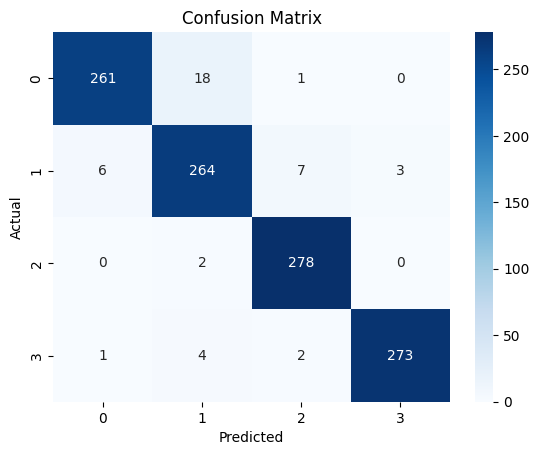

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

testgenerator.reset()
y_pred = model.predict(testgenerator)



y_pred_classes = np.argmax(y_pred, axis=1)




cm = confusion_matrix(testgenerator.classes, y_pred_classes)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()